In [42]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, FancyArrowPatch
import numpy as np
from pathlib import Path
plt.style.use('default')

In [43]:
root_dir = Path('../imgs')
results_dir = root_dir / 'larger_updated'
output_dir = Path('../figs')

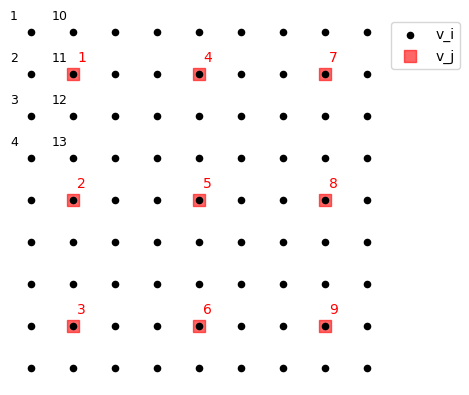

In [44]:
plt.plot(figsize = (12, 6))

x = range(9)
y = range(9)

red_counter = 1  # counter for red boxes

for i in x:
    for j in y:
        # column-wise numbering from top-left
        label = i * 9 + (8 - j) + 1

        is_red = (i - 1) % 3 == 0 and (j - 1) % 3 == 0

        if is_red:
            plt.scatter(i, j, color='red', alpha=0.6, s=80, marker='s', label = 'v_j')

            # column index (left → right)
            red_col = (i - 1) // 3

            # row index (top → bottom)
            red_row = (7 - j) // 3   # flip so top = 0

            # column-wise numbering
            red_number = red_col * 3 + red_row + 1

            plt.text(i + 0.10, j + 0.30, f'{red_number}', 
                    fontsize=10, color='red')
        plt.scatter(i, j, color='black', s=20, label = 'v_i')

        # label only a few points in the top-left
        if i <= 1 and j >= 5:
            plt.text(i - 0.50, j + 0.30, f'{label}', fontsize=9)

plt.axis('off')
plt.gca().set_aspect('equal', adjustable='box')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(),
           loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig(output_dir / 'grid_pic.png')

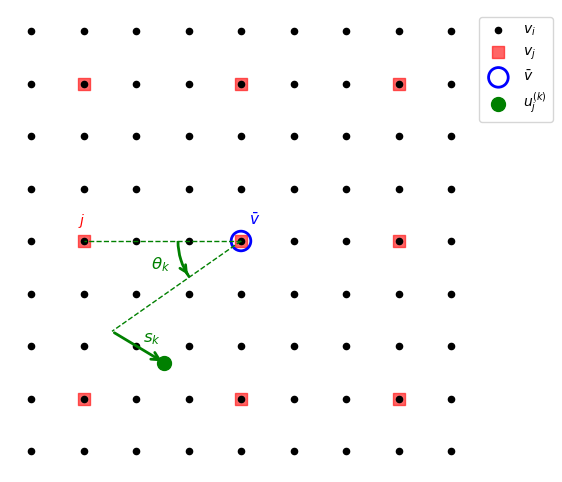

In [45]:
plt.figure(figsize=(12, 6))

x = range(9)
y = range(9)

theta_k = 35  # rotation angle in degrees

# shift vector s_k
s_k = np.array([1.0, -0.6])

for i in x:
    for j in y:

        is_red = (i - 1) % 3 == 0 and (j - 1) % 3 == 0

        if is_red:
            plt.scatter(i, j, color='red', alpha=0.6, s=80, marker='s', label=r'$v_j$')

            red_col = (i - 1) // 3
            red_row = (7 - j) // 3
            red_number = red_col * 3 + red_row + 1

            if red_number == 2:
                plt.text(i - 0.10, j + 0.30, r'$j$',
                         fontsize=10, color='red')

                j2_x, j2_y = i, j

        plt.scatter(i, j, color='black', s=20, label=r'$v_i$')


# center point
center_x, center_y = 4, 4
plt.scatter(center_x, center_y, facecolors='none', edgecolors='blue',
            s=200, linewidths=2, label=r'$\bar v$')
plt.text(center_x + 0.15, center_y + 0.30, r'$\bar v$',
         color='blue', fontsize=11)


# rotation of j = 2 around v-bar
dx = j2_x - center_x
dy = j2_y - center_y

theta_rad = np.deg2rad(theta_k)

rot_x = center_x + dx * np.cos(theta_rad) - dy * np.sin(theta_rad)
rot_y = center_y + dx * np.sin(theta_rad) + dy * np.cos(theta_rad)

# plt.scatter(rot_x, rot_y, color='green', s=90, marker='s',
#             alpha=0.7, label=r'$R^{(k)}(v_j - \bar v) + \bar v$')

plt.plot([center_x, j2_x], [center_y, j2_y],
         color='green', linestyle='--', linewidth=1)

plt.plot([center_x, rot_x], [center_y, rot_y],
         color='green', linestyle='--', linewidth=1)


# shift from rotated point
u_x = rot_x + s_k[0]
u_y = rot_y + s_k[1]

shift_arrow = FancyArrowPatch((rot_x, rot_y),
                              (u_x, u_y),
                              arrowstyle='->',
                              mutation_scale=14,
                              color='green',
                              linewidth=2)
plt.gca().add_patch(shift_arrow)

plt.text((rot_x + u_x) / 2 + 0.10,
         (rot_y + u_y) / 2 + 0.10,
         r'$s_k$',
         color='green',
         fontsize=12)

plt.scatter(u_x, u_y, color='green', s=100, marker='o',
            label=r'$u_j^{(k)}$')

# plt.text(u_x + 0.15, u_y + 0.15,
#          r'$u_2^{(k)}$',
#          color='green',
#          fontsize=12, zorder = 100)


# arc showing theta_k
radius = 1.2
start_angle = np.rad2deg(np.arctan2(dy, dx))
end_angle = start_angle + theta_k

arc = Arc((center_x, center_y),
          width=2 * radius,
          height=2 * radius,
          angle=0,
          theta1=start_angle,
          theta2=end_angle,
          color='green',
          linewidth=2)

plt.gca().add_patch(arc)

arrow_angle = np.deg2rad(end_angle)
arrow_x = center_x + radius * np.cos(arrow_angle)
arrow_y = center_y + radius * np.sin(arrow_angle)

arrow_prev_angle = np.deg2rad(end_angle - 6)
arrow_prev_x = center_x + radius * np.cos(arrow_prev_angle)
arrow_prev_y = center_y + radius * np.sin(arrow_prev_angle)

arrow = FancyArrowPatch((arrow_prev_x, arrow_prev_y),
                        (arrow_x, arrow_y),
                        arrowstyle='->',
                        mutation_scale=12,
                        color='green',
                        linewidth=2)

plt.gca().add_patch(arrow)

label_angle = np.deg2rad(start_angle + theta_k / 2)
plt.text(center_x + 1.8 * np.cos(label_angle),
         center_y + 1.8 * np.sin(label_angle),
         r'$\theta_k$',
         color='green',
         fontsize=12)


plt.axis('off')
plt.gca().set_aspect('equal', adjustable='box')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(),
           loc='upper left', bbox_to_anchor=(1, 1))

plt.savefig(output_dir / 'grid_shift_pic.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

# Displaying the HR / LR images

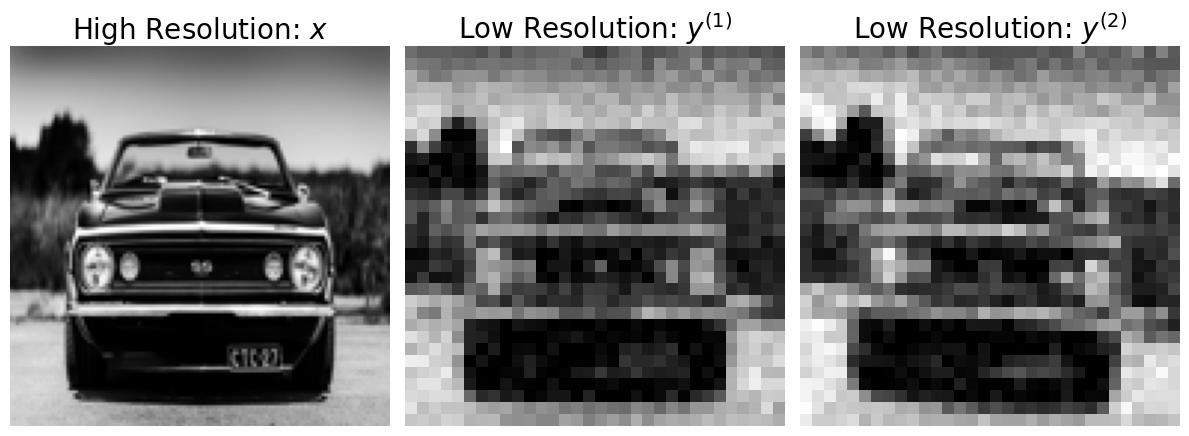

In [46]:
imgHR = plt.imread(root_dir / 'hr_small.png')
imgb  = plt.imread(results_dir / 'data' / 'lr' / 'lr_0.png')
imgc  = plt.imread(results_dir / 'data' / 'lr' / 'lr_1.png')


# Create 1x3 layout
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Plot images
axes[0].imshow(imgHR, cmap = 'grey')
axes[0].set_title("High Resolution: $x$", size = 20)
axes[0].axis("off")

axes[1].imshow(imgb, cmap = 'grey')
axes[1].set_title("Low Resolution: $y^{(1)}$", size = 20)
axes[1].axis("off")

axes[2].imshow(imgc, cmap = 'grey')
axes[2].set_title("Low Resolution: $y^{(2)}$", size = 20)
axes[2].axis("off")

plt.tight_layout()
plt.savefig(output_dir / 'hr_lr.png')
plt.show()


# Reconstructions

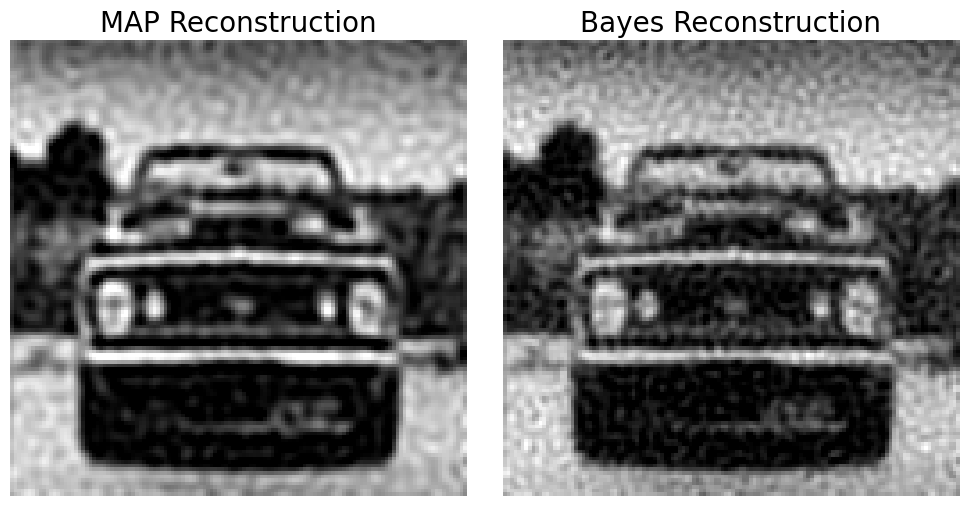

In [47]:
img_bayes  = plt.imread(results_dir / 'bayes' / 'full' / 'reconstruction.png')
img_map  = plt.imread(results_dir / 'map' / 'full' / 'reconstruction.png')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[1].imshow(img_bayes, cmap = 'grey')
axes[1].set_title("Bayes Reconstruction", size = 20)
axes[1].axis("off")

axes[0].imshow(img_map, cmap = 'grey')
axes[0].set_title("MAP Reconstruction", size = 20)
axes[0].axis("off")

plt.tight_layout()
plt.savefig(output_dir / 'recons.png')
plt.show()


In [48]:

plot_rot = plt.imread(results_dir / 'plots' / 'rotation_abs_error_deg.png')
plt_map  = plt.imread(results_dir / 'plots' / 'shift_2d_comparison.png')

plt.imsave(output_dir / 'rotation_abs_error_deg.png', plot_rot)
plt.imsave(output_dir / 'shift_2d_comparison.png', plt_map)

In [49]:

# Load the images
bayes_loss = plt.imread(results_dir / 'bayes' / 'patch' / 'loss' / 'loss_plot.png')
map_loss = plt.imread(results_dir / 'map' / 'full' / 'loss' / 'loss_plot.png')

plt.imsave(output_dir / 'map_loss_plot.png', map_loss)
plt.imsave(output_dir / 'bayes_loss_plot.png', bayes_loss)